# Load Excel File into DataFrame

In [347]:
import pandas as pd
import numpy as np

file_path = "Telco_customer_churn.xlsx"
df = pd.read_excel(file_path)

# Inspect DataFrame Shape and Columns

In [348]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (7043, 33)
Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


# Preview Top Rows

In [349]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.9641,-118.2728,Male,...,Month-to-month,Yes,Mailed check,53.8500,108.1500,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.0593,-118.3074,Female,...,Month-to-month,Yes,Electronic check,70.7000,151.6500,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.0480,-118.2940,Female,...,Month-to-month,Yes,Electronic check,99.6500,820.5000,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.0621,-118.3157,Female,...,Month-to-month,Yes,Electronic check,104.8000,3046.0500,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.0392,-118.2663,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.7000,5036.3000,Yes,1,89,5340,Competitor had better devices


# Check Data Types

In [350]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

# Count Missing Values

In [351]:
df.isna().sum().sort_values(ascending=False)

CustomerID           0
Online Security      0
CLTV                 0
Churn Score          0
Churn Value          0
Churn Label          0
Total Charges        0
Monthly Charges      0
Payment Method       0
Paperless Billing    0
Contract             0
Streaming Movies     0
Streaming TV         0
Tech Support         0
Device Protection    0
Online Backup        0
Internet Service     0
Count                0
Multiple Lines       0
Phone Service        0
Tenure Months        0
Dependents           0
Partner              0
Senior Citizen       0
Gender               0
Longitude            0
Latitude             0
Lat Long             0
Zip Code             0
City                 0
State                0
Country              0
Churn Reason         0
dtype: int64

# Standardize Column Names

In [352]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)
list(df.columns)

['customerid',
 'count',
 'country',
 'state',
 'city',
 'zip_code',
 'lat_long',
 'latitude',
 'longitude',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure_months',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn_label',
 'churn_value',
 'churn_score',
 'cltv',
 'churn_reason']

# Handle Missing Values

In [353]:
# Fill numeric with median and categorical with mode.
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    else:
        if df[col].isna().any():
            mode_vals = df[col].mode(dropna=True)
            fill_val = mode_vals.iloc[0] if not mode_vals.empty else ""
            df[col] = df[col].fillna(fill_val)

# Remove Duplicate Rows

In [354]:
before = len(df)
df = df.drop_duplicates()
removed = before - len(df)
print("Duplicates removed:", removed)

Duplicates removed: 0


# Convert Data Types

In [355]:
# Attempt to convert object columns that are mostly numeric.
for col in df.select_dtypes(include="object").columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    numeric_ratio = converted.notna().mean()
    if numeric_ratio >= 0.9:
        df[col] = converted

# Validate Final Schema

In [356]:
{
    "dtypes": df.dtypes,
    "missing_values": df.isna().sum().sort_values(ascending=False)
}

{'dtypes': customerid            object
 count                  int64
 country               object
 state                 object
 city                  object
 zip_code               int64
 lat_long              object
 latitude             float64
 longitude            float64
 gender                object
 senior_citizen        object
 partner               object
 dependents            object
 tenure_months          int64
 phone_service         object
 multiple_lines        object
 internet_service      object
 online_security       object
 online_backup         object
 device_protection     object
 tech_support          object
 streaming_tv          object
 streaming_movies      object
 contract              object
 paperless_billing     object
 payment_method        object
 monthly_charges      float64
 total_charges        float64
 churn_label           object
 churn_value            int64
 churn_score            int64
 cltv                   int64
 churn_reason          object


# Save Cleaned Data

In [357]:
output_path = "Telco_customer_churn_cleaned.csv"
df.to_csv(output_path, index=False)
print("Saved:", output_path)

Saved: Telco_customer_churn_cleaned.csv


## KPIs

In [358]:
import pandas as pd

file_path = "Telco_customer_churn_cleaned.csv"
cdf = pd.read_csv(file_path)

In [359]:
cdf.tail()

,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.3417,-116.5394,Female,...,Two year,Yes,Bank transfer (automatic),21.1500,1419.4000,No,0,45,5306,Still taking service
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.6678,-117.5362,Male,...,One year,Yes,Mailed check,84.8000,1990.5000,No,0,59,2140,Still taking service
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.5599,-115.6372,Female,...,One year,Yes,Credit card (automatic),103.2000,7362.9000,No,0,71,5560,Still taking service
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.1678,-116.8643,Female,...,Month-to-month,Yes,Electronic check,29.6000,346.4500,No,0,59,2793,Still taking service
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.4249,-117.1845,Male,...,Two year,Yes,Bank transfer (automatic),105.6500,6844.5000,No,0,38,5097,Still taking service


In [360]:
import pandas as pd
import numpy as np

Customer_churn_rate = (np.count_nonzero(cdf["churn_value"] == 1)/len(cdf))
print("Customer Churn Rate:", Customer_churn_rate)

Customer Churn Rate: 0.2653698707936959


In [361]:
Gross_revenue_churn_rate = cdf.loc[cdf["churn_value"] == 1, "monthly_charges"].sum()
print("Gross Revenue Churn Rate per month:", Gross_revenue_churn_rate)


Gross Revenue Churn Rate per month: 139130.85


In [362]:
Net_revenue_churn_rate = cdf.loc[cdf["churn_value"] == 1, "monthly_charges"].sum() - cdf.loc[cdf["churn_value"] == 0, "monthly_charges"].sum()
print("Net Revenue Churn Rate per month:", Net_revenue_churn_rate)

Net Revenue Churn Rate per month: -177854.9


In [363]:
Average_revenue_per_user = cdf.loc[cdf["churn_value"] == 0, "total_charges"].sum() / len(cdf['churn_value']==0)
print(Average_revenue_per_user)

Revenue_churn_rate = Average_revenue_per_user/Customer_churn_rate
print("Revenue_churn_rate per year: ", Revenue_churn_rate)

1873.2417719721711
Revenue_churn_rate per year:  7058.984376672017


/var/folders/6b/jgk7rrk92zqdc3hd7dxmz75h0000gn/T/ipykernel_47956/3706727899.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = cdf.groupby(["contract", "churn_value"]).size().unstack(fill_value=0)


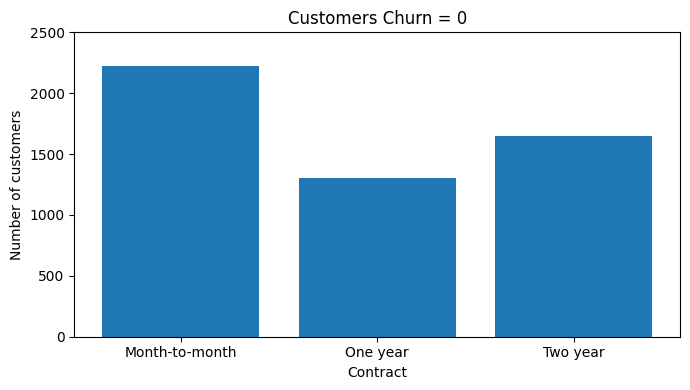

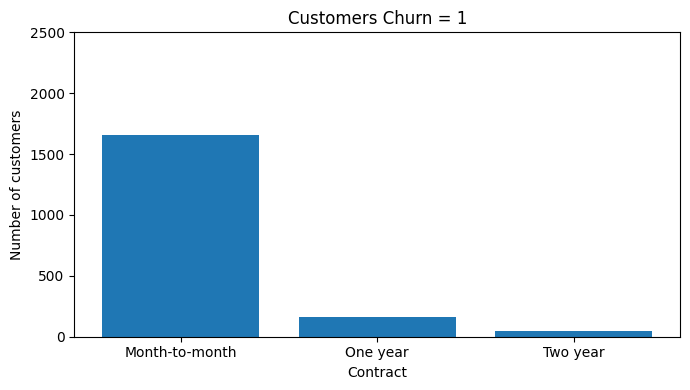

In [364]:
import pandas as pd
import matplotlib.pyplot as plt


contract_order = ["Month-to-month", "One year", "Two year"]
cdf["contract"] = pd.Categorical(cdf["contract"], categories=contract_order, ordered=True)

# Count customers by contract for each churn value
counts = cdf.groupby(["contract", "churn_value"]).size().unstack(fill_value=0)
counts = counts.reindex(contract_order)  # keep desired order

# Plot: churn_value = 0
plt.figure(figsize=(7, 4))
plt.bar(counts.index.astype(str), counts[0].values)
plt.title("Customers Churn = 0")
plt.xlabel("Contract")
plt.ylabel("Number of customers")
plt.ylim(0, 2500)
plt.tight_layout()
plt.show()

# Plot: churn_value = 1
plt.figure(figsize=(7, 4))
plt.bar(counts.index.astype(str), counts[1].values)
plt.title("Customers Churn = 1")
plt.xlabel("Contract")
plt.ylabel("Number of customers")
plt.ylim(0, 2500)
plt.tight_layout()
plt.show()


/var/folders/6b/jgk7rrk92zqdc3hd7dxmz75h0000gn/T/ipykernel_47956/770017597.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = cdf.groupby(["payment_method", "churn_value"]).size().unstack(fill_value=0)


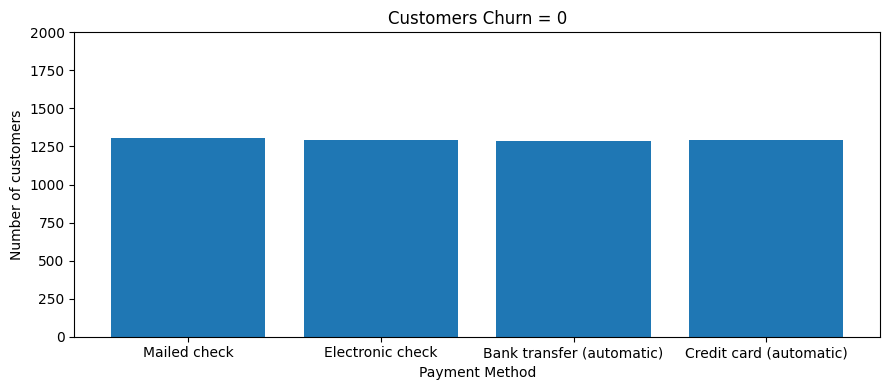

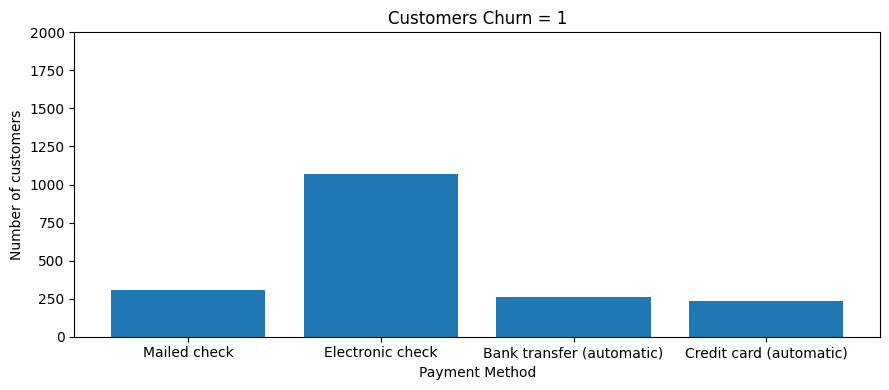

In [365]:
Payment_order = ["Mailed check", "Electronic check", "Bank transfer (automatic)", "Credit card (automatic)"]
cdf["payment_method"] = pd.Categorical(cdf["payment_method"], categories=Payment_order, ordered=True)

# Count customers by payment method for each churn value
counts = cdf.groupby(["payment_method", "churn_value"]).size().unstack(fill_value=0)
counts = counts.reindex(Payment_order)  # keep desired order

# Plot: churn_value = 0
plt.figure(figsize=(9, 4))
plt.bar(counts.index.astype(str), counts[0].values)
plt.title("Customers Churn = 0")
plt.xlabel("Payment Method")
plt.ylabel("Number of customers")
plt.ylim(0, 2000)
plt.tight_layout()
plt.show()

# Plot: churn_value = 1
plt.figure(figsize=(9, 4))
plt.bar(counts.index.astype(str), counts[1].values)
plt.title("Customers Churn = 1")
plt.xlabel("Payment Method")
plt.ylabel("Number of customers")
plt.ylim(0, 2000)
plt.tight_layout()
plt.show()


/var/folders/6b/jgk7rrk92zqdc3hd7dxmz75h0000gn/T/ipykernel_47956/1721889902.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = cdf.groupby(["internet_service", "churn_value"]).size().unstack(fill_value=0)


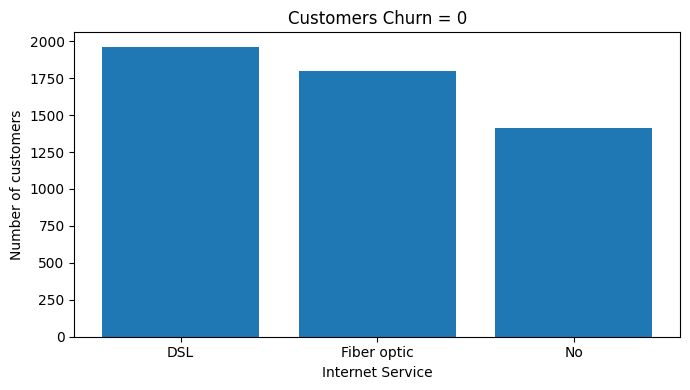

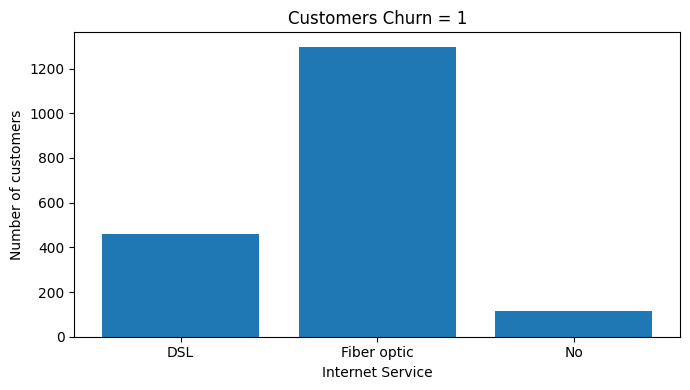

In [366]:
import pandas as pd
import matplotlib.pyplot as plt



internet_service_order = ["DSL", "Fiber optic", "No"]
cdf["internet_service"] = pd.Categorical(cdf["internet_service"], categories=internet_service_order, ordered=True)

# Count customers by internet service for each churn value
counts = cdf.groupby(["internet_service", "churn_value"]).size().unstack(fill_value=0)
counts = counts.reindex(internet_service_order)  # keep desired order

# Plot: churn_value = 0
plt.figure(figsize=(7, 4))
plt.bar(counts.index.astype(str), counts[0].values)
plt.title("Customers Churn = 0")
plt.xlabel("Internet Service")
plt.ylabel("Number of customers")
# plt.ylim(0, 2500)
plt.tight_layout()
plt.show()

# Plot: churn_value = 1
plt.figure(figsize=(7, 4))
plt.bar(counts.index.astype(str), counts[1].values)
plt.title("Customers Churn = 1")
plt.xlabel("Internet Service")
plt.ylabel("Number of customers")
# plt.ylim(0, 2500)
plt.tight_layout()
plt.show()

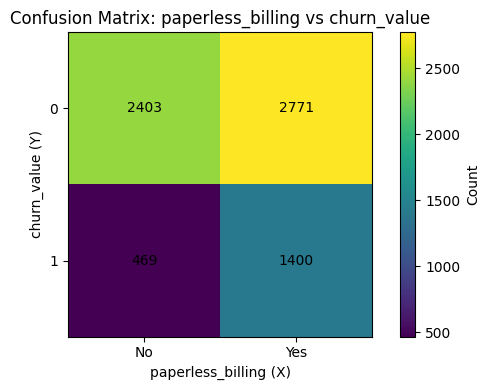

paperless_billing    No   Yes
churn_value                  
0                  2403  2771
1                   469  1400


In [367]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cm = pd.crosstab(cdf["churn_value"], cdf["paperless_billing"])  # rows=Y, cols=X

plt.figure(figsize=(6,4))
plt.imshow(cm.values)  # heatmap look (default colors)
plt.xticks(np.arange(cm.shape[1]), cm.columns.astype(str))
plt.yticks(np.arange(cm.shape[0]), cm.index.astype(str))
plt.xlabel("paperless_billing (X)")
plt.ylabel("churn_value (Y)")
plt.title("Confusion Matrix: paperless_billing vs churn_value")

# Annotate counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm.values[i, j], ha="center", va="center")

plt.colorbar(label="Count")
plt.tight_layout()
plt.show()

# If you also want to see the table:
print(cm)

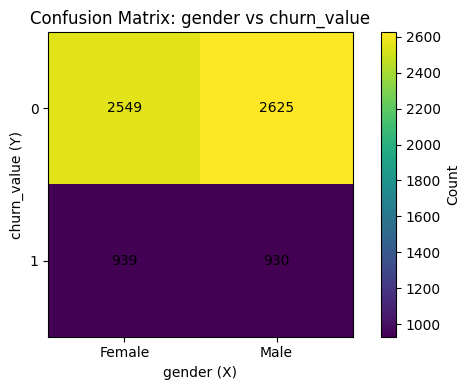

gender       Female  Male
churn_value              
0              2549  2625
1               939   930


In [368]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cm = pd.crosstab(cdf["churn_value"], cdf["gender"])  # rows=Y, cols=X

plt.figure(figsize=(6,4))
plt.imshow(cm.values)  # heatmap look (default colors)
plt.xticks(np.arange(cm.shape[1]), cm.columns.astype(str))
plt.yticks(np.arange(cm.shape[0]), cm.index.astype(str))
plt.xlabel("gender (X)")
plt.ylabel("churn_value (Y)")
plt.title("Confusion Matrix: gender vs churn_value")

# Annotate counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm.values[i, j], ha="center", va="center")

plt.colorbar(label="Count")
plt.tight_layout()
plt.show()

# If you also want to see the table:
print(cm)

In [369]:
# Simple Jupyter cell: tabulate churn rate by city (assumes `cdf` is already loaded)
import pandas as pd

# --- Settings ---
CITY_KEYWORD = "city"           # column must contain this substring (case-insensitive)
CHURN_KEYWORD = "churn_value"   # column must contain this substring (case-insensitive)
SHOW_TOP = None                 # set to an int to show only top N rows, or None to show all


# --- find columns (simple heuristic) ---
cols_lower = {c: c.lower() for c in cdf.columns}
city_col = next((c for c, lc in cols_lower.items() if CITY_KEYWORD in lc), None)
churn_col = next((c for c, lc in cols_lower.items() if CHURN_KEYWORD in lc), None)

if city_col is None or churn_col is None:
    raise ValueError(f"Couldn't find columns containing '{CITY_KEYWORD}' and/or '{CHURN_KEYWORD}'. "
                     f"Available columns: {list(cdf.columns)}")

# --- normalize churn to boolean (treat 1 / '1' / 'yes' / True as churn) ---
def is_churn(v):
    if pd.isna(v):
        return False
    if isinstance(v, (int, float)):
        return int(v) == 1
    s = str(v).strip().lower()
    return s in {"1", "yes", "y", "true", "t"}

df = cdf.copy()
df[city_col] = df[city_col].fillna("Unknown")
df["_is_churn"] = df[churn_col].apply(is_churn)

# --- aggregate: total, churned, churn_rate ---

# simpler explicit approach to avoid pandas version quirks:
totals = df.groupby(city_col).size().reset_index(name="total")
churned = df[df["_is_churn"]].groupby(city_col).size().reset_index(name="churned")
summary = totals.merge(churned, on=city_col, how="left").fillna(0)
summary["churned"] = summary["churned"].astype(int)
summary["churn_rate"] = summary["churned"] / summary["total"]

# --- sort by churn_rate descending and format percentage column ---
summary = summary.sort_values("churn_rate", ascending=False).reset_index(drop=True)
summary["churn_rate_pct"] = (summary["churn_rate"] * 100).round(2)

# reorder columns for readability
summary = summary[[city_col, "total", "churned", "churn_rate", "churn_rate_pct"]]

# show results
if SHOW_TOP:
    display(summary.head(SHOW_TOP))
else:
    display(summary)



,city,total,churned,churn_rate,churn_rate_pct
0,Fort Jones,4,4,1.0000,100.0000
1,Eldridge,4,4,1.0000,100.0000
2,Maricopa,4,4,1.0000,100.0000
3,Boulder Creek,4,4,1.0000,100.0000
4,Riverbank,4,4,1.0000,100.0000
...,...,...,...,...,...
1124,North Highlands,4,0,0.0000,0.0000
1125,Nipton,4,0,0.0000,0.0000
1126,Coleville,4,0,0.0000,0.0000
1127,Newbury Park,5,0,0.0000,0.0000


In [370]:
import pandas as pd

# Numerical features
numerical_features = cdf.select_dtypes(include=['number'])
num_numerical = numerical_features.shape[1]

# Categorical features
categorical_features = cdf.select_dtypes(include=['object', 'category'])
num_categorical = categorical_features.shape[1]

print("Number of numerical features:", num_numerical)
print("Number of categorical features:", num_categorical)

Number of numerical features: 10
Number of categorical features: 23


In [371]:
# Get class counts
class_counts = cdf['churn_value'].value_counts()

print("Class distribution:")
print(class_counts)

# Calculate imbalance ratio (minority / majority)
imbalance_ratio = class_counts.min() /  class_counts.max()

print("\nImbalance Ratio (Minority / Majority):", imbalance_ratio)

Class distribution:
churn_value
0    5174
1    1869
Name: count, dtype: int64

Imbalance Ratio (Minority / Majority): 0.36122922303826827


## Possible Data Leakage Columns
- churn Label
- Churn Score
- CTLV (Customer Life Time Value)
- Churn Reason

#### These columns have to deleted from the table to prevent data leakage 

In [372]:
# List of columns to drop
cols_to_drop = [
    'churn_label',
    'churn_score',
    'cltv',
    'churn_reason',
    'customerid',
    'count',
    'lat_long',
    'latitude',
    'longitude',
    'state',
    'country',
    'zip_code',
    'total_charges'
]

# Create new dataframe without those columns
df_model = cdf.drop(columns=cols_to_drop, errors='ignore')

# Quick check
print("Original shape:", cdf.shape)
print("New shape:", df_model.shape)

Original shape: (7043, 33)
New shape: (7043, 20)


In [373]:
# Select categorical columns
categorical_cols = df_model.select_dtypes(include=['object', 'category'])

# Count unique values
cardinality = categorical_cols.nunique().sort_values(ascending=False)

print(cardinality)

city                 1129
payment_method          4
multiple_lines          3
internet_service        3
online_backup           3
device_protection       3
tech_support            3
streaming_tv            3
streaming_movies        3
contract                3
online_security         3
senior_citizen          2
partner                 2
dependents              2
phone_service           2
gender                  2
paperless_billing       2
dtype: int64


In [374]:
high_card_cols = cardinality[cardinality > 50]

print("High-cardinality columns:")
print(high_card_cols)

High-cardinality columns:
city    1129
dtype: int64


In [375]:
yes_no_cols = [
    'senior_citizen', 'partner', 'dependents',
    'phone_service', 'paperless_billing', 'multiple_lines',
    'online_security', 'online_backup',
    'streaming_movies', 'streaming_tv',
    'tech_support', 'device_protection'
]

for col in yes_no_cols:
    df_model[col] = df_model[col].replace('No internet service', 'No')
    df_model[col] = df_model[col].replace('No phone service', 'No')
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

In [376]:
# # Frequency encoding for city
# freq_map = df_model['city'].value_counts()

# df_model['city_freq'] = df_model['city'].map(freq_map)

# # Optionally drop original column
# df_model = df_model.drop(columns=['city'])

In [377]:
cols_to_encode = ['contract', 'internet_service', 'payment_method']

# find created dummy columns that start with any of the encoded prefixes
df_model = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True)
ohe_cols = [c for c in df_model.columns if any(c.startswith(prefix + '_') for prefix in cols_to_encode)]
print("One-hot columns detected:", ohe_cols)

# cast them to int
df_model[ohe_cols] = df_model[ohe_cols].astype(int)

One-hot columns detected: ['contract_One year', 'contract_Two year', 'internet_service_Fiber optic', 'internet_service_No', 'payment_method_Electronic check', 'payment_method_Bank transfer (automatic)', 'payment_method_Credit card (automatic)']


In [378]:
# normalize strings, inspect uniques & counts
df_model['gender'] = df_model['gender'].astype(str).str.strip().str.title()
print(df_model['gender'].value_counts(dropna=False))

# map to binary (choose mapping consistently)
df_model['gender_bin'] = df_model['gender'].map({'Female': 1, 'Male': 0})


# drop original if you want
df_model = df_model.drop(columns=['gender'])

gender
Male      3555
Female    3488
Name: count, dtype: int64


In [379]:
from sklearn.preprocessing import StandardScaler
import joblib

# columns you want to scale
num_cols = ['tenure_months', 'monthly_charges']   # <- replace with your two column names
                # if present, ensure it's not in num_cols

# optional: verify columns exist
missing = [c for c in num_cols if c not in df_model.columns]
if missing:
    raise KeyError(f"Columns not found in df_model: {missing}")

# fit scaler on these columns and transform in-place
scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

# (optional) save scaler for later use
joblib.dump(scaler, 'standardscaler_two_cols.joblib')

# quick check
print(df_model[num_cols].describe().loc[['mean','std']])

      tenure_months  monthly_charges
mean        -0.0000          -0.0000
std          1.0001           1.0001


In [380]:
df_model.head()

,city,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,online_security,online_backup,device_protection,...,monthly_charges,churn_value,contract_One year,contract_Two year,internet_service_Fiber optic,internet_service_No,payment_method_Electronic check,payment_method_Bank transfer (automatic),payment_method_Credit card (automatic),gender_bin
0,Los Angeles,0,0,0,-1.2367,1,0,1,1,0,...,-0.3627,1,0,0,0,0,0,0,0,0
1,Los Angeles,0,0,1,-1.2367,1,0,0,0,0,...,0.1974,1,0,0,1,0,1,0,0,1
2,Los Angeles,0,0,1,-0.9924,1,1,0,0,1,...,1.1595,1,0,0,1,0,1,0,0,1
3,Los Angeles,0,1,1,-0.1780,1,1,0,0,1,...,1.3307,1,0,0,1,0,1,0,0,1
4,Los Angeles,0,0,1,0.6771,1,1,0,1,1,...,1.2942,1,0,0,1,0,0,1,0,0


In [381]:
from sklearn.model_selection import train_test_split

TARGET = 'churn_value'

# 1) stratified split (keep city present)
train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=42, stratify=df_model[TARGET]
)

# 2) compute normalized city frequency from TRAIN only
freq_map_norm_train = train_df['city'].value_counts(normalize=True)

# 3) map onto both sets; unseen cities -> 0.0
train_df['city_freq'] = train_df['city'].map(freq_map_norm_train).fillna(0.0)
test_df['city_freq']  = test_df['city'].map(freq_map_norm_train).fillna(0.0)

# 4) drop original city if you don't want it as a categorical feature
train_df = train_df.drop(columns=['city'])
test_df  = test_df.drop(columns=['city'])

# 5) build X/y
X_train = train_df.drop(columns=[TARGET]).reset_index(drop=True)
y_train = train_df[TARGET].reset_index(drop=True)

X_test  = test_df.drop(columns=[TARGET]).reset_index(drop=True)
y_test  = test_df[TARGET].reset_index(drop=True)

In [382]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

# Make copies to be safe
Xtr = train_df.copy()
Xte = test_df.copy()

# 1) Ensure target isn't in feature frames
TARGET = 'churn_value'
if TARGET in Xtr.columns:
    print("Dropping target from Xtr (it should be in y_train).")
    Xtr = Xtr.drop(columns=[TARGET])
if TARGET in Xte.columns:
    print("Dropping target from Xte (it should be in y_test).")
    Xte = Xte.drop(columns=[TARGET])

# 2) Make sure X_test has same columns as X_train (same order)
Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

print("X_train columns count:", Xtr.shape[1])
print("X_test columns count: ", Xte.shape[1])


Dropping target from Xtr (it should be in y_train).
Dropping target from Xte (it should be in y_test).
X_train columns count: 23
X_test columns count:  23


In [383]:

# 3) (Optional) show any mismatch - should be none now
missing_in_test = set(Xtr.columns) - set(Xte.columns)
missing_in_train = set(Xte.columns) - set(Xtr.columns)
print("Missing in test (should be empty):", missing_in_test)
print("Missing in train (should be empty):", missing_in_train)

Missing in test (should be empty): set()
Missing in train (should be empty): set()


In [384]:
# Convert bools to ints if any (prevents imputer/estimator dtype issues)
bool_cols = Xtr.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    Xtr[bool_cols] = Xtr[bool_cols].astype(int)
    Xte[bool_cols] = Xte[bool_cols].astype(int)

# Re-fit models on corrected Xtr and y_train
log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
rf_model  = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
hgb_model = HistGradientBoostingClassifier(max_iter=200, class_weight='balanced', random_state=42)

In [385]:
print("Fitting LogisticRegression...")
log_model.fit(Xtr, y_train)

print("Fitting RandomForest...")
rf_model.fit(Xtr, y_train)

print("Fitting HistGradientBoosting...")
hgb_model.fit(Xtr, y_train)

Fitting LogisticRegression...
Fitting RandomForest...
Fitting HistGradientBoosting...


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

In [386]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except Exception:
        y_prob = None

    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else float('nan')
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n== {name} ==")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    return dict(name=name, roc=roc, precision=prec, recall=rec, f1=f1)


In [387]:
print("Logistic Regression")
_ = evaluate_model("LogisticRegression", log_model, Xte, y_test)

Logistic Regression

== LogisticRegression ==
ROC-AUC: 0.8467
Precision: 0.5108
Recall: 0.7594
F1: 0.6108
Confusion Matrix:
 [[763 272]
 [ 90 284]]


In [388]:
print("Random Forest")
_ = evaluate_model("RandomForest", rf_model, Xte, y_test)

Random Forest

== RandomForest ==
ROC-AUC: 0.8353
Precision: 0.6238
Recall: 0.5053
F1: 0.5583
Confusion Matrix:
 [[921 114]
 [185 189]]


In [389]:
print("HistGradientBoosting")
_ = evaluate_model("HistGradientBoosting", hgb_model, Xte, y_test)

HistGradientBoosting

== HistGradientBoosting ==
ROC-AUC: 0.8338
Precision: 0.5349
Recall: 0.7166
F1: 0.6126
Confusion Matrix:
 [[802 233]
 [106 268]]


Best model by ROC-AUC: log_model ROC-AUC: 0.8466506497197034
ROC-AUC on test: 0.8467

Best threshold maximizing F1: 0.5881  (F1 = 0.6333)


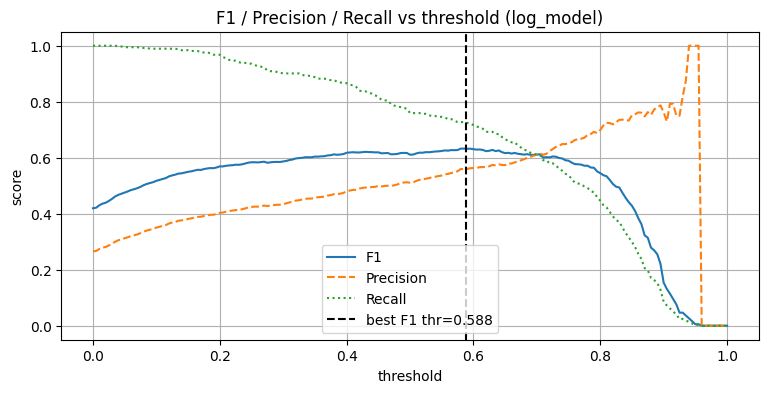


Threshold achieving recall >= 0.85: 0.0000 (precision=0.2654, recall=1.0000)

== Default 0.5 (thr=0.500) ==
ROC-AUC (score-based): 0.8467
Precision: 0.5108, Recall: 0.7594, F1: 0.6108
Confusion matrix (tn, fp, fn, tp): [763 272  90 284]

== Best-F1 (thr=0.588) ==
ROC-AUC (score-based): 0.8467
Precision: 0.5608, Recall: 0.7273, F1: 0.6333
Confusion matrix (tn, fp, fn, tp): [822 213 102 272]

== Business recall >= 0.85 (thr=0.000) ==
ROC-AUC (score-based): 0.8467
Precision: 0.2654, Recall: 1.0000, F1: 0.4195
Confusion matrix (tn, fp, fn, tp): [   0 1035    0  374]

Summary table:


,precision,recall,f1,cm
threshold,,,,
0.0000,0.2654,1.0000,0.4195,"[[0, 1035], [0, 374]]"
0.5000,0.5108,0.7594,0.6108,"[[763, 272], [90, 284]]"
0.5881,0.5608,0.7273,0.6333,"[[822, 213], [102, 272]]"


In [390]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# ---------- helpers ----------
def get_score_array(model, X):
    """Return positive-class score array for model or pipeline."""
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)[:, 1]
        except Exception:
            pass
    if hasattr(model, "decision_function"):
        try:
            # decision scores are fine for ranking; convert to 0..1 for plotting if needed
            from scipy.special import expit
            return expit(model.decision_function(X))
        except Exception:
            return model.decision_function(X)
    # fallback: discrete predict -> convert to float (not ideal for thresholding)
    return np.asarray(model.predict(X), dtype=float)

# ---------- 1) pick best fitted model by roc_auc (ignore NaN rows) ----------
ranked = modelsranking.copy()
ranked = ranked.dropna(subset=['roc_auc']).reset_index(drop=True)
if ranked.empty:
    raise RuntimeError("No fitted models with ROC-AUC found. Fit models first.")
best_model_name = ranked.loc[0, 'model']
best_model = models[best_model_name]
print("Best model by ROC-AUC:", best_model_name, "ROC-AUC:", ranked.loc[0, 'roc_auc'])

# ---------- 2) get scores on validation/test (use holdout/val ideally) ----------
scores = get_score_array(best_model, X_test)
roc = roc_auc_score(y_test, scores)
print(f"ROC-AUC on test: {roc:.4f}")

# ---------- 3) sweep thresholds and compute F1 / Precision / Recall ----------
precisions, recalls, thresholds = precision_recall_curve(y_test, scores)
# thresholds length = len(precisions)-1 ; align F1 to thresholds
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
f1s_for_thresholds = f1s[:-1]      # drop last value which corresponds to threshold beyond last
thresholds_arr = thresholds

# find best F1 and threshold
best_idx = int(np.nanargmax(f1s_for_thresholds))
best_threshold = float(thresholds_arr[best_idx])
best_f1 = float(f1s_for_thresholds[best_idx])
print(f"\nBest threshold maximizing F1: {best_threshold:.4f}  (F1 = {best_f1:.4f})")

# ---------- plot F1 vs threshold (and precision/recall) ----------
grid = np.linspace(0,1,201)
f1_grid = []
prec_grid = []
rec_grid = []
for t in grid:
    yhat = (scores >= t).astype(int)
    f1_grid.append(f1_score(y_test, yhat, zero_division=0))
    prec_grid.append(precision_score(y_test, yhat, zero_division=0))
    rec_grid.append(recall_score(y_test, yhat, zero_division=0))

plt.figure(figsize=(9,4))
plt.plot(grid, f1_grid, label="F1")
plt.plot(grid, prec_grid, label="Precision", linestyle='--')
plt.plot(grid, rec_grid, label="Recall", linestyle=':')
plt.axvline(best_threshold, color='k', linestyle='--', label=f"best F1 thr={best_threshold:.3f}")
plt.xlabel("threshold"); plt.ylabel("score"); plt.title(f"F1 / Precision / Recall vs threshold ({best_model_name})")
plt.legend(); plt.grid(True); plt.show()

# ---------- 4) optional: find threshold to reach a target recall (business) ----------
def find_threshold_for_recall(scores, y_true, target_recall=0.85, min_precision=None):
    grid = np.linspace(0,1,1001)
    candidates = []
    for t in grid:
        yhat = (scores >= t).astype(int)
        prec = precision_score(y_true, yhat, zero_division=0)
        rec = recall_score(y_true, yhat, zero_division=0)
        if rec >= target_recall and (min_precision is None or prec >= min_precision):
            candidates.append((t, prec, rec))
    if not candidates:
        return None
    # choose lowest threshold meeting the constraint (most sensitive)
    return min(candidates, key=lambda x: x[0])

# example business target: recall >= 0.85 (adjust to your needs)
target_recall = 0.85
min_precision = None   # optionally set a floor, e.g. 0.15
thr_candidate = find_threshold_for_recall(scores, y_test, target_recall=target_recall, min_precision=min_precision)
if thr_candidate is None:
    print(f"\nNo threshold achieves recall >= {target_recall:.2f} (with min_precision={min_precision}).")
else:
    thr_rec, prec_at_thr, rec_at_thr = thr_candidate
    print(f"\nThreshold achieving recall >= {target_recall:.2f}: {thr_rec:.4f} (precision={prec_at_thr:.4f}, recall={rec_at_thr:.4f})")

# ---------- 5) report metrics at default 0.5, best-F1, and business-threshold (if found) ----------
def report_at_threshold(threshold, label):
    yhat = (scores >= threshold).astype(int)
    roc = roc_auc_score(y_test, scores)
    prec = precision_score(y_test, yhat, zero_division=0)
    rec = recall_score(y_test, yhat, zero_division=0)
    f1v = f1_score(y_test, yhat, zero_division=0)
    cm = confusion_matrix(y_test, yhat)
    print(f"\n== {label} (thr={threshold:.3f}) ==")
    print(f"ROC-AUC (score-based): {roc:.4f}")
    print(f"Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1v:.4f}")
    print("Confusion matrix (tn, fp, fn, tp):", cm.ravel())
    return dict(threshold=threshold, precision=prec, recall=rec, f1=f1v, cm=cm)

res_default = report_at_threshold(0.5, "Default 0.5")
res_bestf1  = report_at_threshold(best_threshold, "Best-F1")
res_business = None
if thr_candidate is not None:
    thr_rec = thr_candidate[0]
    res_business = report_at_threshold(thr_rec, f"Business recall >= {target_recall:.2f}")

# ---------- 6) Return summary table ----------
summary = pd.DataFrame([res_default, res_bestf1] + ([res_business] if res_business else []))
summary_indexed = summary.set_index('threshold').sort_index()
print("\nSummary table:")
display(summary_indexed)

In [391]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Use best model from ranking
best_model_name = modelsranking.dropna().iloc[0]['model']
best_model = models[best_model_name]

print("Optimizing recall for model:", best_model_name)

# Get probability scores
if hasattr(best_model, "predict_proba"):
    scores = best_model.predict_proba(X_test)[:, 1]
else:
    from scipy.special import expit
    scores = expit(best_model.decision_function(X_test))

# Sweep thresholds
thresholds = np.linspace(0, 1, 1001)

best_recall = 0
best_threshold = 0.5
best_precision = 0

for t in thresholds:
    y_pred = (scores >= t).astype(int)
    recall = recall_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)

    # maximize recall (optionally add precision constraint)
    if recall > best_recall:
        best_recall = recall
        best_threshold = t
        best_precision = precision

print("\nBest threshold for maximum recall:")
print("Threshold:", round(best_threshold, 4))
print("Recall:", round(best_recall, 4))
print("Precision:", round(best_precision, 4))

# Evaluate at this threshold
y_opt = (scores >= best_threshold).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_opt))

print("\nF1 Score:", f1_score(y_test, y_opt))

Optimizing recall for model: log_model

Best threshold for maximum recall:
Threshold: 0.0
Recall: 1.0
Precision: 0.2654

Confusion Matrix:
[[   0 1035]
 [   0  374]]

F1 Score: 0.4195176668536175


In [392]:
target_recall = 0.85

candidate = None

for t in thresholds:
    y_pred = (scores >= t).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)

    if recall >= target_recall:
        candidate = (t, recall, precision)
        break  # first threshold that achieves target recall

if candidate:
    print("\nThreshold achieving recall >= 0.85:")
    print("Threshold:", candidate[0])
    print("Recall:", candidate[1])
    print("Precision:", candidate[2])
else:
    print("No threshold achieves the target recall.")


Threshold achieving recall >= 0.85:
Threshold: 0.0
Recall: 1.0
Precision: 0.2654364797728886


“Since churn detection prioritizes catching churners, I optimized the decision threshold to maximize recall rather than using the default 0.5. This improved churn capture significantly, at the cost of precision, which aligns with business retention strategy.”

## SHAP

In [393]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 18.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 21.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 20.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]3/5 [numba]te]


In [395]:
# 1) show model expected features (if available)
if hasattr(hgb_model, "feature_names_in_"):
    print("Model.feature_names_in_ length:", len(hgb_model.feature_names_in_))
    print("First 10 feature names the model saw:", hgb_model.feature_names_in_[:10])
else:
    print("Model has no feature_names_in_ attribute (maybe trained on numpy array).")

# 2) check X_train / X_test shapes and columns
print("X_train shape:", X_train.shape)
try:
    print("X_train columns (first 10):", list(X_train.columns[:10]))
except Exception:
    print("X_train has no .columns (maybe numpy).")

print("X_test shape:", X_test.shape)
try:
    print("X_test columns (first 10):", list(X_test.columns[:10]))
except Exception:
    print("X_test has no .columns (maybe numpy).")

# 3) show any mismatch between model feature names and X_test columns
if hasattr(hgb_model, "feature_names_in_") and hasattr(X_test, "columns"):
    set_model = list(hgb_model.feature_names_in_)
    set_X = list(X_test.columns)
    print("Columns in model but missing in X_test:", [c for c in set_model if c not in set_X][:20])
    print("Columns in X_test but not in model:", [c for c in set_X if c not in set_model][:20])
    # If both sets mostly match, check ordering
    if set_model == set_X:
        print("Feature names exactly match (and order).")
    else:
        # show first mismatch index
        for i, (a,b) in enumerate(zip(set_model, set_X)):
            if a != b:
                print("First mismatch at index", i, "model had", a, "but X_test had", b)
                break

Model.feature_names_in_ length: 23
First 10 feature names the model saw: ['senior_citizen' 'partner' 'dependents' 'tenure_months' 'phone_service'
 'multiple_lines' 'online_security' 'online_backup' 'device_protection'
 'tech_support']
X_train shape: (5634, 23)
X_train columns (first 10): ['senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'online_security', 'online_backup', 'device_protection', 'tech_support']
X_test shape: (1409, 23)
X_test columns (first 10): ['senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'online_security', 'online_backup', 'device_protection', 'tech_support']
Columns in model but missing in X_test: []
Columns in X_test but not in model: []
Feature names exactly match (and order).


In [396]:
import shap
import numpy as np

# create explainer that explains probabilities
explainer = shap.TreeExplainer(hgb_model, X_train, model_output="probability")

# compute shap values for a subset first (faster)
X_sample = X_test.sample(200, random_state=42)   # small subset to debug
shap_values = explainer(X_sample)               # modern API

# quick check: compare sums to model probabilities
if hasattr(hgb_model, "predict_proba"):
    model_probs = hgb_model.predict_proba(X_sample)[:, 1]
else:
    from scipy.special import expit
    model_probs = expit(hgb_model.decision_function(X_sample))

# shap_values.values shape may be (n_samples, n_features) or (n_samples, n_features, 2)
vals = shap_values.values
if vals.ndim == 3:
    # pick positive-class shap values
    vals_pos = vals[:, :, 1]
    base = shap_values.base_values[:, 1] if shap_values.base_values.ndim > 0 else shap_values.base_values
else:
    vals_pos = vals
    base = shap_values.base_values

shap_sum = vals_pos.sum(axis=1) + np.ravel(base)
diff = model_probs - shap_sum
print("max abs diff:", np.max(np.abs(diff)))
print("mean abs diff:", np.mean(np.abs(diff)))

max abs diff: 0.10417525560693536
mean abs diff: 0.003521459104040844


In [398]:
import numpy as np

print("shap_values.values shape:", shap_values.values.shape)
print("shap_values.base_values shape:", np.array(shap_values.base_values).shape)
print("explainer.expected_value (if present):", getattr(shap_values, "base_values", None)[:5] if hasattr(shap_values, "base_values") else None)

shap_values.values shape: (200, 23)
shap_values.base_values shape: (200,)
explainer.expected_value (if present): [0.3686679 0.3686679 0.3686679 0.3686679 0.3686679]


In [400]:
import numpy as np

# assume X_sample was created earlier as: X_sample = X_test.sample(200, random_state=42)
# and shap_values were computed on X_sample: shap_values = explainer(X_sample)

# 1) get model probs for the SAME subset
if hasattr(hgb_model, "predict_proba"):
    model_probs_sample = hgb_model.predict_proba(X_sample)[:, 1]
else:
    from scipy.special import expit
    model_probs_sample = expit(hgb_model.decision_function(X_sample))

# 2) extract shap arrays (positive class) for sample
vals = shap_values.values
if vals.ndim == 3:
    shap_vals_pos = vals[:, :, 1]    # shape (n_sample, n_features)
    # base values: either scalar per sample or per-class
    base_vals = np.ravel(shap_values.base_values) if np.array(shap_values.base_values).ndim == 1 else np.ravel(shap_values.base_values[:,1])
else:
    shap_vals_pos = vals
    base_vals = np.ravel(shap_values.base_values)

# 3) compute sums and diffs (same length)
shap_sums_sample = shap_vals_pos.sum(axis=1) + base_vals
diffs = model_probs_sample - shap_sums_sample
abs_diffs = np.abs(diffs)

# 4) summary and top offenders
print("sample size:", len(model_probs_sample))
print("max abs diff (sample):", abs_diffs.max())
print("mean abs diff (sample):", abs_diffs.mean())
print("median abs diff (sample):", np.median(abs_diffs))

top_idx = np.argsort(-abs_diffs)[:10]   # indices within X_sample (0..199)
for j, i in enumerate(top_idx, 1):
    print(f"\nTOP {j} sample index_in_sample={i} | model_prob={model_probs_sample[i]:.6f} | shap_sum={shap_sums_sample[i]:.6f} | diff={diffs[i]:+.6f}")
    top_feats = np.argsort(-np.abs(shap_vals_pos[i]))[:8]
    for fi in top_feats:
        feat_name = X_sample.columns[fi]
        feat_val = X_sample.iloc[i, fi]
        print(f"  {feat_name:30s} shap={shap_vals_pos[i,fi]:+.6f} value={feat_val}")

sample size: 200
max abs diff (sample): 0.10417525560693536
mean abs diff (sample): 0.003521459104040844
median abs diff (sample): 0.0010134033718246227

TOP 1 sample index_in_sample=34 | model_prob=0.202122 | shap_sum=0.306298 | diff=-0.104175
  tenure_months                  shap=+0.191698 value=-1.2367242199587352
  monthly_charges                shap=-0.115623 value=-1.4727407520661506
  internet_service_No            shap=-0.103859 value=1
  internet_service_Fiber optic   shap=-0.095807 value=0
  contract_One year              shap=+0.043963 value=0
  contract_Two year              shap=+0.033429 value=0
  dependents                     shap=+0.025586 value=0
  streaming_movies               shap=-0.023151 value=0

TOP 2 sample index_in_sample=47 | model_prob=0.224907 | shap_sum=0.141125 | diff=+0.083782
  dependents                     shap=-0.161663 value=1
  tenure_months                  shap=+0.145393 value=-1.2367242199587352
  internet_service_No            shap=-0.109025 v

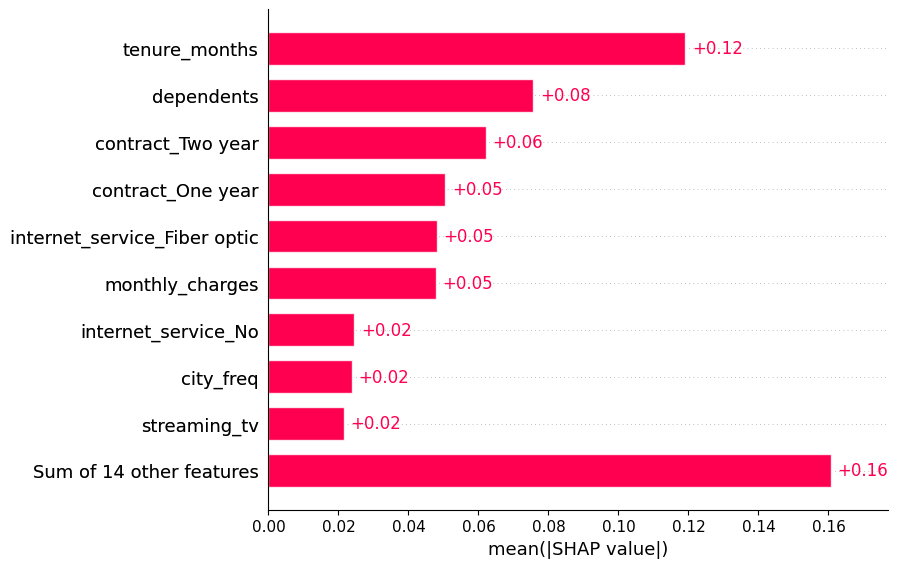

In [408]:
# global importance
shap.plots.bar(shap_values) 

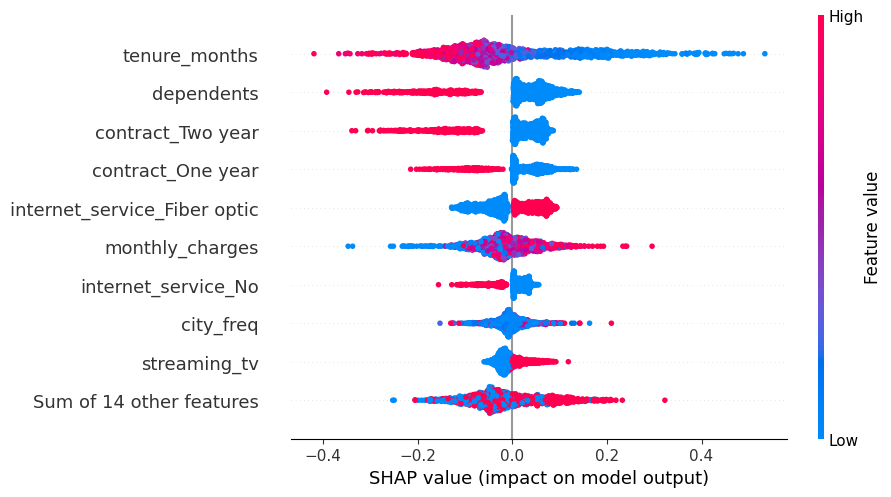

In [409]:
# summary beeswarm
shap.plots.beeswarm(shap_values)

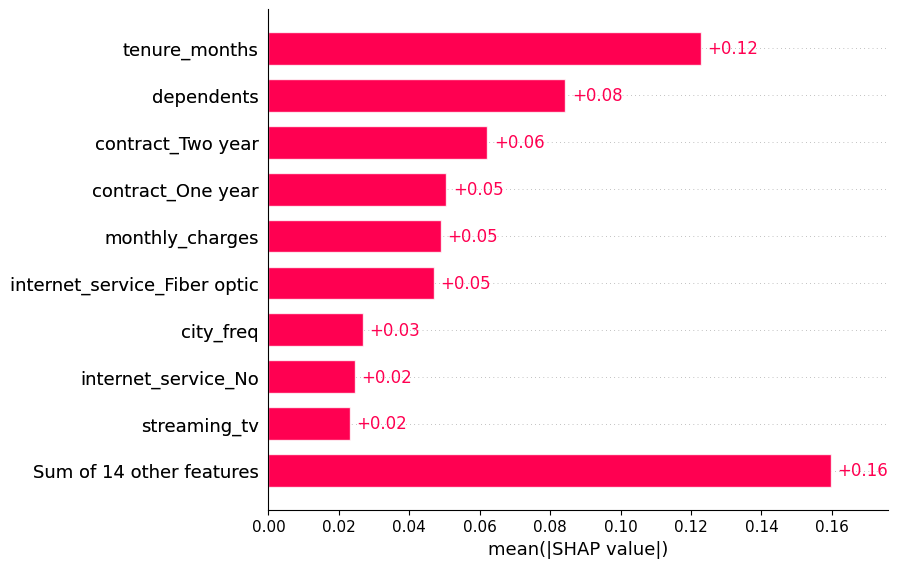

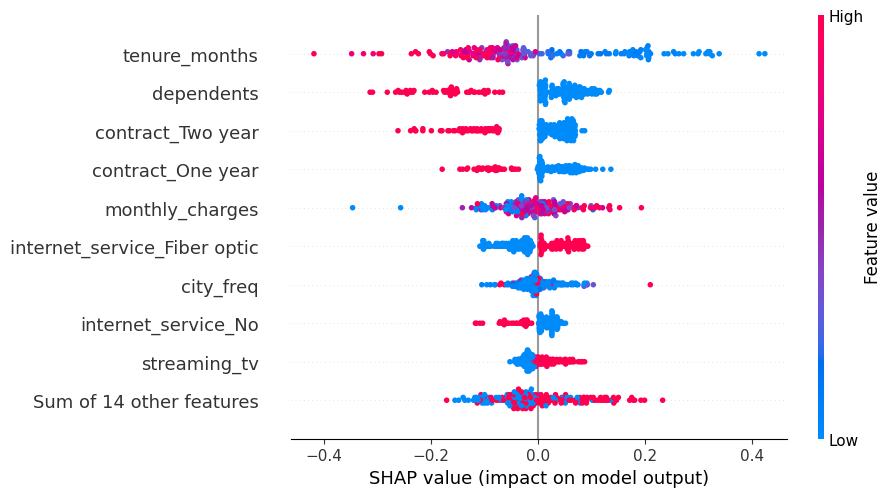

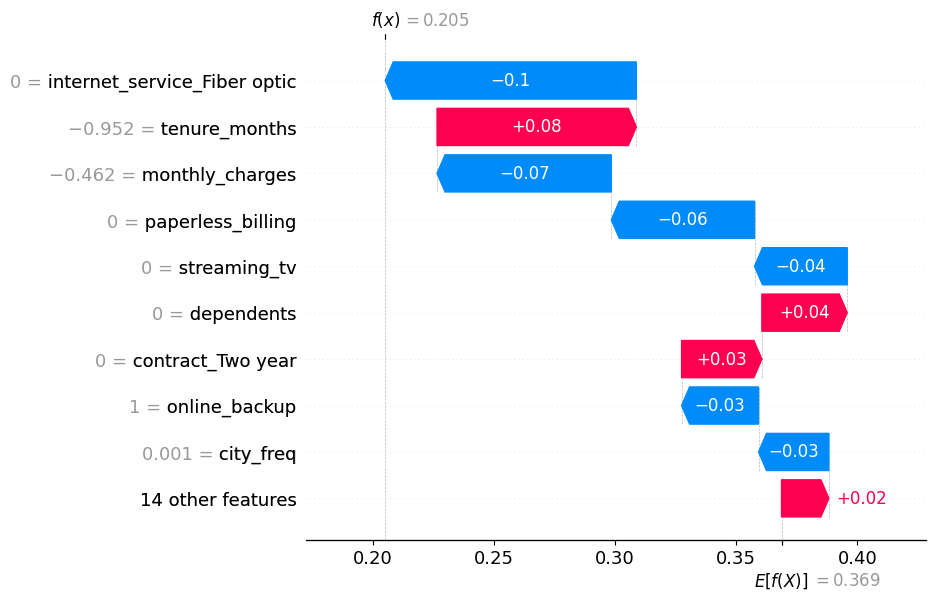

In [ ]:
       # bar plot of mean absolute SHAP values

# summary beeswarm
shap.plots.beeswarm(shap_values)

# explain one sample (waterfall)
idx = 0
shap.plots.waterfall(shap_values[idx])

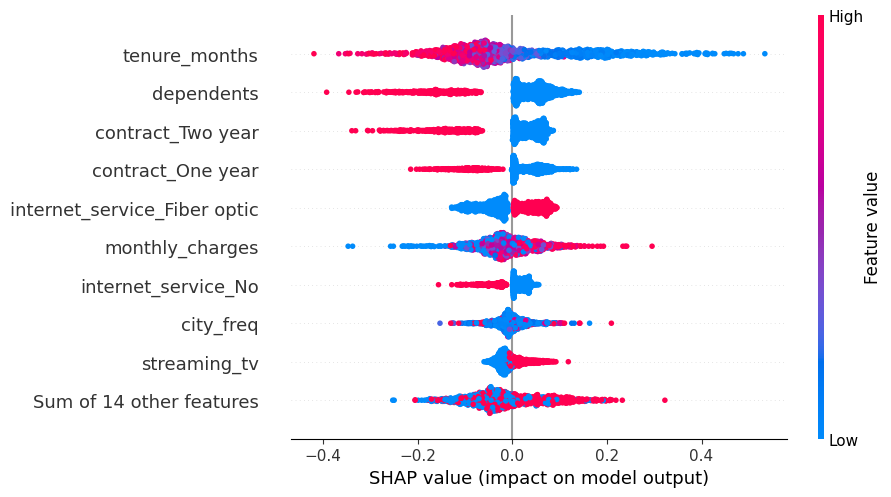

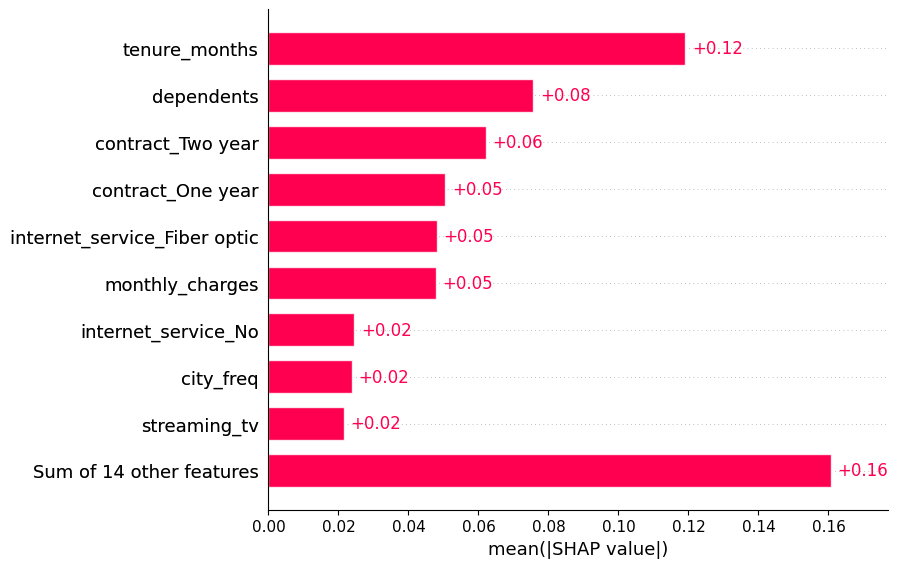

In [402]:
explainer = shap.TreeExplainer(
    hgb_model,
    X_train,
    model_output="probability"
)

shap_values = explainer(X_test, check_additivity=False)

shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)

The model confirms that churn risk is highest among short-tenure, month-to-month, fiber-optic customers with high monthly charges. Long-term contracts and having dependents significantly reduce churn risk.

## Retention Simulation

In [403]:
import numpy as np
import pandas as pd

# ---------- Inputs (edit) ----------
avg_revenue = 100.0        # X: average revenue per customer (e.g. lifetime value or next-period revenue)
cost_per_customer = 10.0   # Y: cost to run retention campaign per targeted customer
target_pct = 0.20          # target top 20% highest-risk
effectiveness = 0.30       # assumed fraction of churns prevented among those who would churn (30%)

# ---------- Helper: get positive-class score ----------
def get_score_array(model, X):
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)[:, 1]
        except Exception:
            pass
    if hasattr(model, "decision_function"):
        from scipy.special import expit
        return expit(model.decision_function(X))
    return np.asarray(model.predict(X), dtype=float)

# choose the model to simulate (use best_model if set; else try models dict)
try:
    model_to_use = best_model
except NameError:
    # fallback: pick top non-NaN roc model from modelsranking
    model_to_use = None
    if 'modelsranking' in globals() and 'models' in globals():
        mr = modelsranking.dropna()
        if len(mr)>0:
            model_to_use = models[mr.iloc[0]['model']]
if model_to_use is None:
    raise RuntimeError("No fitted model found in variable best_model or models/modelsranking. Set best_model first.")

# ---------- Score X_test ----------
scores = get_score_array(model_to_use, X_test)
df_sim = pd.DataFrame({
    'score': scores,
    'y_true': y_test.values if hasattr(y_test, "values") else np.asarray(y_test)
})

# ---------- Select top-k highest risk ----------
N = len(df_sim)
N_target = int(np.ceil(N * target_pct))
df_sorted = df_sim.sort_values('score', ascending=False).reset_index(drop=True)
target_group = df_sorted.iloc[:N_target].copy()
non_target_group = df_sorted.iloc[N_target:].copy()

# ---------- Expected churns (before intervention) ----------
expected_churns_target = target_group['score'].sum()        # sum of probs ≈ expected number of churners in group
expected_churns_nt = non_target_group['score'].sum()

# ---------- Expected prevented churn ----------
expected_prevented_churn = effectiveness * expected_churns_target

# ---------- Financials ----------
total_campaign_cost = N_target * cost_per_customer
gross_revenue_saved = expected_prevented_churn * avg_revenue
net_revenue_lift = gross_revenue_saved - total_campaign_cost
roi = (gross_revenue_saved / total_campaign_cost) if total_campaign_cost>0 else np.nan
revenue_per_dollar_spent = (gross_revenue_saved / total_campaign_cost) if total_campaign_cost>0 else np.nan
cost_per_prevented_churn = (total_campaign_cost / expected_prevented_churn) if expected_prevented_churn>0 else np.nan

# ---------- Reporting ----------
report = {
    'N_population': N,
    'target_pct': target_pct,
    'N_target': N_target,
    'expected_churns_target (before)': expected_churns_target,
    'expected_churns_non_target (before)': expected_churns_nt,
    'expected_prevented_churn (eff={})'.format(effectiveness): expected_prevented_churn,
    'avg_revenue_per_customer': avg_revenue,
    'cost_per_customer': cost_per_customer,
    'total_campaign_cost': total_campaign_cost,
    'gross_revenue_saved': gross_revenue_saved,
    'net_revenue_lift': net_revenue_lift,
    'ROI (gross_saved / campaign_cost)': roi,
    'cost_per_prevented_churn': cost_per_prevented_churn
}
report_df = pd.Series(report)
print(report_df.to_frame('value'))

# ---------- Optional: quick sensitivity sweep ----------
def sweep_effectiveness(effs=[0.1,0.2,0.3,0.4,0.5]):
    rows = []
    for eff in effs:
        prevented = eff * expected_churns_target
        gross = prevented * avg_revenue
        cost = total_campaign_cost
        net = gross - cost
        roi_ = gross/cost if cost>0 else np.nan
        rows.append({'effectiveness':eff, 'prevented_churn':prevented, 'gross_saved':gross, 'net_lift':net, 'roi':roi_})
    return pd.DataFrame(rows)

print("\nSensitivity to effectiveness:")
display(sweep_effectiveness([0.05,0.1,0.2,0.3,0.4,0.5]))

                                        value
N_population                        1409.0000
target_pct                             0.2000
N_target                             282.0000
expected_churns_target (before)      240.4770
expected_churns_non_target (before)  335.2489
expected_prevented_churn (eff=0.3)    72.1431
avg_revenue_per_customer             100.0000
cost_per_customer                     10.0000
total_campaign_cost                 2820.0000
gross_revenue_saved                 7214.3104
net_revenue_lift                    4394.3104
ROI (gross_saved / campaign_cost)      2.5583
cost_per_prevented_churn              39.0890

Sensitivity to effectiveness:


,effectiveness,prevented_churn,gross_saved,net_lift,roi
0,0.0500,12.0239,1202.3851,-1617.6149,0.4264
1,0.1000,24.0477,2404.7701,-415.2299,0.8528
2,0.2000,48.0954,4809.5403,1989.5403,1.7055
3,0.3000,72.1431,7214.3104,4394.3104,2.5583
4,0.4000,96.1908,9619.0805,6799.0805,3.4110
5,0.5000,120.2385,12023.8507,9203.8507,4.2638


Model used: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Top picks:
Best by net lift:
target_pct                     0.6700
N_target                     945.0000
net_revenue_lift           23305.4080
gross_revenue_saved        32755.4080
total_campaign_cost         9450.0000
expected_prevented_churn     163.7770
avg_prob_in_target             0.5777
Name: 66, dtype: float64

Best by ROI:
target_pct                   0.0100
N_target                    15.0000
ROI                          5.6174
net_revenue_lift           692.6162
gross_revenue_saved        842.6162
total_campaign_cost        150.0000
expected_prevented_churn     4.2131
avg_prob_in_target           0.9362
Name: 0, dtype: float64


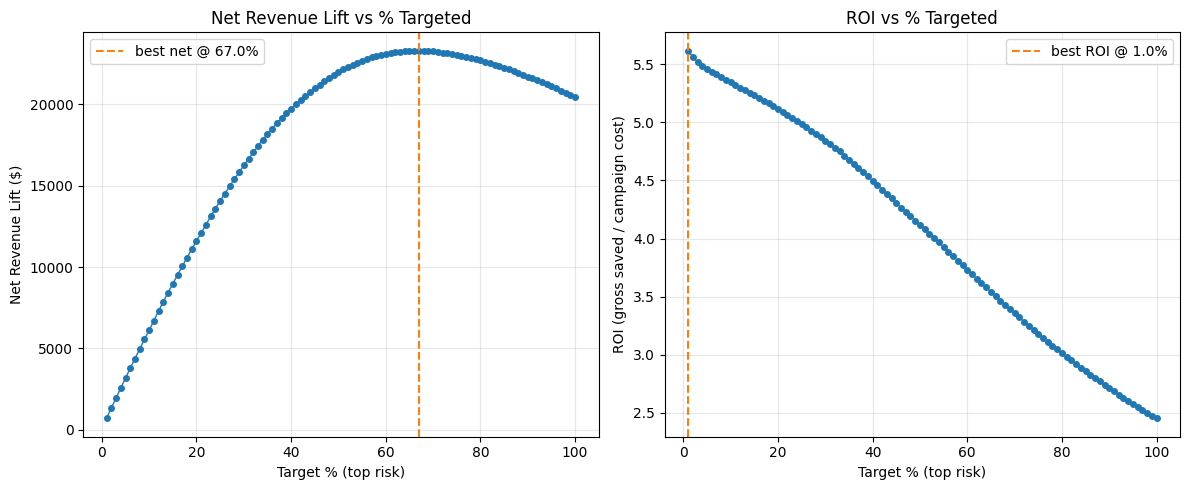


Sample of results (first 20 rows):


,target_pct,N_target,avg_prob_in_target,expected_churns_target,expected_prevented_churn,total_campaign_cost,gross_revenue_saved,net_revenue_lift,ROI,precision_in_target_observed
0,0.0100,15,0.9362,14.0436,4.2131,150.0000,842.6162,692.6162,5.6174,0.7333
1,0.0200,29,0.9271,26.8871,8.0661,290.0000,1613.2279,1323.2279,5.5629,0.7931
2,0.0300,43,0.9201,39.5647,11.8694,430.0000,2373.8804,1943.8804,5.5207,0.7674
3,0.0400,57,0.9146,52.1304,15.6391,570.0000,3127.8220,2557.8220,5.4874,0.7719
4,0.0500,71,0.9102,64.6270,19.3881,710.0000,3877.6171,3167.6171,5.4614,0.7746
5,0.0600,85,0.9063,77.0384,23.1115,850.0000,4622.3070,3772.3070,5.4380,0.7529
6,0.0700,99,0.9022,89.3161,26.7948,990.0000,5358.9648,4368.9648,5.4131,0.7576
7,0.0800,113,0.8982,101.4938,30.4482,1130.0000,6089.6303,4959.6303,5.3891,0.7611
8,0.0900,127,0.8944,113.5849,34.0755,1270.0000,6815.0929,5545.0929,5.3662,0.7638
9,0.1000,141,0.8907,125.5861,37.6758,1410.0000,7535.1658,6125.1658,5.3441,0.7589



Row around best net lift:


,target_pct,N_target,avg_prob_in_target,expected_churns_target,expected_prevented_churn,total_campaign_cost,gross_revenue_saved,net_revenue_lift,ROI,precision_in_target_observed
63,0.6400,902,0.5966,538.1055,161.4317,9020.0000,32286.3328,23266.3328,3.5794,0.4013
64,0.6500,916,0.5904,540.8209,162.2463,9160.0000,32449.2520,23289.2520,3.5425,0.3963
65,0.6600,930,0.5843,543.3738,163.0121,9300.0000,32602.4262,23302.4262,3.5056,0.3925
66,0.6700,945,0.5777,545.9235,163.7770,9450.0000,32755.4080,23305.4080,3.4662,0.3884
67,0.6800,959,0.5716,548.1454,164.4436,9590.0000,32888.7249,23298.7249,3.4295,0.3827
68,0.6900,973,0.5655,550.2299,165.0690,9730.0000,33013.7914,23283.7914,3.3930,0.3782
69,0.7000,987,0.5594,552.1596,165.6479,9870.0000,33129.5740,23259.5740,3.3566,0.3739



Row around best ROI:


,target_pct,N_target,avg_prob_in_target,expected_churns_target,expected_prevented_churn,total_campaign_cost,gross_revenue_saved,net_revenue_lift,ROI,precision_in_target_observed
0,0.0100,15,0.9362,14.0436,4.2131,150.0000,842.6162,692.6162,5.6174,0.7333
1,0.0200,29,0.9271,26.8871,8.0661,290.0000,1613.2279,1323.2279,5.5629,0.7931
2,0.0300,43,0.9201,39.5647,11.8694,430.0000,2373.8804,1943.8804,5.5207,0.7674
3,0.0400,57,0.9146,52.1304,15.6391,570.0000,3127.8220,2557.8220,5.4874,0.7719


100%|██████████| 1000/1000 [00:00<00:00, 18219.94it/s]


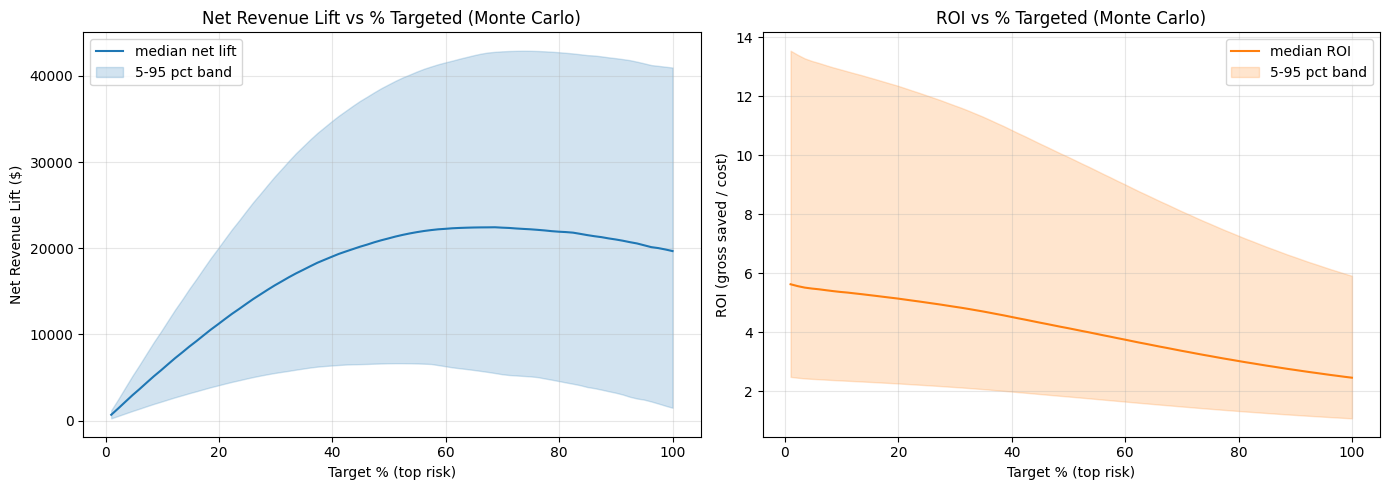

Median net lift positive for target_pct in:  (np.float64(1.0), np.float64(100.0))
5%-percentile net lift positive for target_pct in:  (np.float64(1.0), np.float64(100.0))


In [406]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
from tqdm import trange   # optional progress bar; remove if not installed

# ---------- Settings (edit to reflect your priors) ----------
n_sims = 1000                # Monte Carlo draws (500-2000 usually ok)
n_steps = 80                 # grid points for target% (makes plots smoother)
min_target_pct = 0.01
max_target_pct = 1.0

# Priors / uncertainty distributions — choose sensible distributions!
# These are examples; replace parameters with your best estimates.
eff_mean = 0.30
eff_std = 0.08             # uncertainty in effectiveness (std dev)
# We'll sample effectiveness from truncated normal (clip 0..1)
rev_mean = 200.0
rev_std = 40.0             # avg revenue uncertainty
cost_mean = 10.0
cost_std = 3.0             # campaign cost uncertainty

# Optional: model probability calibration noise (multiplicative)
# This simulates that true churn probs might be off by some factor around 1.0
prob_noise_mean = 1.0
prob_noise_std = 0.05      # 5% multiplicative noise (small)

random_state = 42
rng = np.random.default_rng(random_state)

# ---------- Prepare base data ----------
# We'll use df_sorted (score column sorted descending) if available; otherwise compute
try:
    df_sorted
except NameError:
    # compute from model; assumes model_to_use and X_test exist
    scores = get_score_array(model_to_use, X_test)
    df = pd.DataFrame({'score': scores})
    df_sorted = df.sort_values('score', ascending=False).reset_index(drop=True)

N = len(df_sorted)
target_pcts = np.linspace(min_target_pct, max_target_pct, n_steps)

# allocate results: shape (n_sims, n_steps)
net_lift_sims = np.zeros((n_sims, n_steps))
roi_sims = np.zeros((n_sims, n_steps))

# ---------- Monte Carlo loop ----------
# Use tqdm for progress if installed; if not, change to range(n_sims)
use_tqdm = True
iterator = trange(n_sims) if ('trange' in globals()) else range(n_sims)

for sim in iterator:
    # sample uncertain parameters
    # effectiveness sample (truncated normal between 0 and 1)
    eff = rng.normal(eff_mean, eff_std)
    eff = float(np.clip(eff, 0.0, 1.0))

    avg_revenue = float(max(0.0, rng.normal(rev_mean, rev_std)))
    cost_per_customer = float(max(0.0, rng.normal(cost_mean, cost_std)))

    # optional: multiplicative prob noise (applied to scores)
    prob_noise_factor = float(max(0.0, rng.normal(prob_noise_mean, prob_noise_std)))

    # create noisy scores for this sim
    scores_sim = (df_sorted['score'].values * prob_noise_factor).clip(0.0, 1.0)

    # precompute cumulative sums of sorted scores to speed loop
    # cum_scores[k] = sum of top k scores_sim (k from 1..N)
    cum_scores = np.cumsum(scores_sim)

    for j, pct in enumerate(target_pcts):
        N_target = int(ceil(N * pct))
        if N_target <= 0:
            net_lift_sims[sim, j] = 0.0
            roi_sims[sim, j] = np.nan
            continue

        expected_churns_target = float(cum_scores[N_target-1])   # sum of top N_target probs
        expected_prevented = eff * expected_churns_target
        total_campaign_cost = N_target * cost_per_customer
        gross_saved = expected_prevented * avg_revenue
        net_lift = gross_saved - total_campaign_cost
        roi = (gross_saved / total_campaign_cost) if total_campaign_cost > 0 else np.nan

        net_lift_sims[sim, j] = net_lift
        roi_sims[sim, j] = roi

# ---------- Compute percentiles (median, 5%, 95%) ----------
pct_low = 5
pct_high = 95
net_median = np.nanpercentile(net_lift_sims, 50, axis=0)
net_p05 = np.nanpercentile(net_lift_sims, pct_low, axis=0)
net_p95 = np.nanpercentile(net_lift_sims, pct_high, axis=0)

roi_median = np.nanpercentile(roi_sims, 50, axis=0)
roi_p05 = np.nanpercentile(roi_sims, pct_low, axis=0)
roi_p95 = np.nanpercentile(roi_sims, pct_high, axis=0)

# ---------- Plot with uncertainty bands ----------
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(target_pcts*100, net_median, label='median net lift', color='C0')
plt.fill_between(target_pcts*100, net_p05, net_p95, color='C0', alpha=0.2, label=f'{pct_low}-{pct_high} pct band')
plt.xlabel('Target % (top risk)')
plt.ylabel('Net Revenue Lift ($)')
plt.title('Net Revenue Lift vs % Targeted (Monte Carlo)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(target_pcts*100, roi_median, label='median ROI', color='C1')
plt.fill_between(target_pcts*100, roi_p05, roi_p95, color='C1', alpha=0.2, label=f'{pct_low}-{pct_high} pct band')
plt.xlabel('Target % (top risk)')
plt.ylabel('ROI (gross saved / cost)')
plt.title('ROI vs % Targeted (Monte Carlo)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Quick summary: where median net lift > 0 and 5%-quantile > 0 ----------
median_net_positive = target_pcts[net_median > 0]
p05_net_positive = target_pcts[net_p05 > 0]

print("Median net lift positive for target_pct in: ", (median_net_positive.min()*100 if len(median_net_positive)>0 else None, median_net_positive.max()*100 if len(median_net_positive)>0 else None))
print("5%-percentile net lift positive for target_pct in: ", (p05_net_positive.min()*100 if len(p05_net_positive)>0 else None, p05_net_positive.max()*100 if len(p05_net_positive)>0 else None))

# ---------- Optionally return results as a DataFrame ----------
mc_results = pd.DataFrame({
    'target_pct': target_pcts,
    'net_median': net_median,
    'net_p05': net_p05,
    'net_p95': net_p95,
    'roi_median': roi_median,
    'roi_p05': roi_p05,
    'roi_p95': roi_p95
})

Using Monte Carlo simulation to model uncertainty in campaign effectiveness and revenue, we observe that the retention strategy remains profitable across most targeting levels. The median optimal targeting is around 65–70%, with strong downside protection.

## A/B Testing

Pool size: 282, mean churn prob in pool (p_c) = 0.8528


,n_per_arm,power,mean_p_control,effect
0,50,0.8367,0.8528,0.3000
1,100,0.9853,0.8528,0.3000
2,150,1.0000,0.8528,0.3000
3,200,1.0000,0.8528,0.3000
4,250,1.0000,0.8528,0.3000
5,300,1.0000,0.8528,0.3000
6,350,1.0000,0.8528,0.3000
7,400,1.0000,0.8528,0.3000
8,450,1.0000,0.8528,0.3000
9,500,1.0000,0.8528,0.3000


Estimated per-arm sample size for 80% power: 50


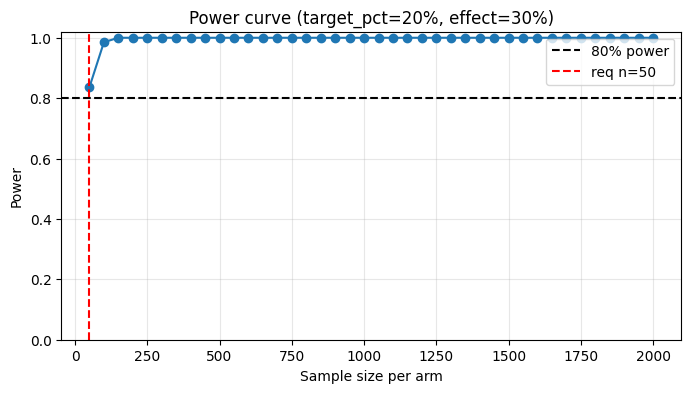

In [407]:
import numpy as np
import pandas as pd
from math import ceil
from scipy.stats import norm
import matplotlib.pyplot as plt

# ---------- helper: two-proportion z-test (pooled) ----------
def two_proportion_z_test(success_a, n_a, success_b, n_b):
    """
    Return z_stat, p_value for H0: p_a == p_b (two-sided).
    success_a: successes in group A (int)
    """
    p_a = success_a / n_a
    p_b = success_b / n_b
    p_pool = (success_a + success_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
    if se == 0:
        return 0.0, 1.0
    z = (p_a - p_b) / se
    pval = 2 * (1 - norm.cdf(abs(z)))
    return z, pval

# ---------- simulation function ----------
def simulate_ab_power(scores, target_pct=0.2, effect=0.30, alpha=0.05,
                      n_per_arm_list=None, n_sims=2000, seed=42, two_sided=True):
    """
    scores: array-like model churn probabilities for the population (unordered).
    target_pct: fraction of the population you'd run the A/B on (top risk). If None, uses full population.
    effect: fraction of churn prevented among would-be churners (e.g. 0.3)
    n_per_arm_list: list/array of candidate sample sizes per arm to evaluate.
    n_sims: number of Monte Carlo experiment repetitions per n.
    Returns DataFrame with power for each n_per_arm.
    """
    rng = np.random.default_rng(seed)
    scores = np.asarray(scores).ravel()
    N = len(scores)
    # choose test pool: top target_pct by score
    if target_pct is not None and 0 < target_pct <= 1:
        k = max(1, int(np.ceil(N * target_pct)))
        pool_scores = np.sort(scores)[-k:][::-1]  # descending top k
    else:
        pool_scores = scores.copy()
        k = len(pool_scores)
    # baseline churn probabilities in the pool
    # We'll randomly draw customers without replacement for each sim,
    # but the distribution of probabilities is pool_scores.
    mean_p = float(np.mean(pool_scores))
    print(f"Pool size: {k}, mean churn prob in pool (p_c) = {mean_p:.4f}")

    # default sizes to try
    if n_per_arm_list is None:
        n_per_arm_list = np.unique(np.ceil(np.geomspace(20, min(2000, k//2), 20)).astype(int))  # rough default

    results = []
    for n in n_per_arm_list:
        if n*2 > k:
            # can't draw without replacement; allow sampling with replacement but warn
            pass

        n_success = 0
        for sim in range(n_sims):
            # sample indices for A and B (random without replacement if possible)
            if 2*n <= k:
                idx = rng.choice(k, size=2*n, replace=False)
            else:
                idx = rng.choice(k, size=2*n, replace=True)
            idx_a, idx_b = idx[:n], idx[n:]
            p_a = pool_scores[idx_a]  # array of probabilities for control group
            p_b = pool_scores[idx_b]  # for treatment group, we'll reduce by effect

            # draw Bernoulli outcomes
            y_a = rng.binomial(1, p_a)
            # treatment reduces churn by multiplicative factor (1 - effect)
            p_b_treated = p_b * (1 - effect)
            # ensure valid 0..1
            p_b_treated = np.clip(p_b_treated, 0.0, 1.0)
            y_b = rng.binomial(1, p_b_treated)

            s_a = int(y_a.sum())
            s_b = int(y_b.sum())

            _, pval = two_proportion_z_test(s_a, n, s_b, n)
            if pval < alpha:
                n_success += 1

        power = n_success / n_sims
        results.append({'n_per_arm': int(n), 'power': power,
                        'mean_p_control': float(np.mean(pool_scores)), 'effect': effect})
    df_res = pd.DataFrame(results).sort_values('n_per_arm').reset_index(drop=True)
    return df_res

# ---------- helper: find required sample size for desired power ----------
def required_sample_size_from_sim(df_power, target_power=0.8):
    """Given output df from simulate_ab_power, return smallest n_per_arm achieving target_power."""
    ok = df_power[df_power['power'] >= target_power]
    if ok.empty:
        return None
    return int(ok['n_per_arm'].iloc[0])

# ---------- Example usage ----------
# Use your model scores (e.g., scores = get_score_array(best_model, X_test))
# For demo, we'll assume variable `scores` exists (as in earlier steps).
# Replace target_pct, effect, alpha, n_sims as desired.

# Example parameters (edit to your needs)
target_pct = 0.20     # run A/B on top 20% risk group
effect = 0.30         # expect 30% of would-be churn prevented in treatment
alpha = 0.05
n_sims = 1500
n_per_arm_list = np.arange(50, 2001, 50)  # sample sizes per arm to sweep

# Run sim (this may take some time depending on n_sims and n_per_arm_list)
df_power = simulate_ab_power(scores, target_pct=target_pct, effect=effect,
                             alpha=alpha, n_per_arm_list=n_per_arm_list, n_sims=n_sims)

# Show result & find required n
display(df_power.head(10))
req_n = required_sample_size_from_sim(df_power, target_power=0.8)
print("Estimated per-arm sample size for 80% power:", req_n)

# Plot power curve
plt.figure(figsize=(8,4))
plt.plot(df_power['n_per_arm'], df_power['power'], marker='o')
plt.axhline(0.8, color='k', linestyle='--', label='80% power')
if req_n:
    plt.axvline(req_n, color='r', linestyle='--', label=f'req n={req_n}')
plt.xlabel('Sample size per arm')
plt.ylabel('Power')
plt.title(f'Power curve (target_pct={target_pct*100:.0f}%, effect={effect*100:.0f}%)')
plt.ylim(0,1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()